# Module 4 — Time-Series Forecasting for Capacity Planning

Welcome to your hands-on journey into AIOps forecasting! In this notebook, you'll learn to predict future system capacity needs before they become critical problems.

**Real-World Challenge**: Transform from reactive firefighting to proactive capacity planning using statistical forecasting models.

## Lesson 4.1 — Why Forecasting Matters in AIOps

**Goal**: Understand the business value of forecasting and identify the most critical metric for capacity planning

### Demonstration: Loading Data and System Analysis

Let's start by analyzing our system's current state and identifying the most critical metric:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the capacity planning dataset
df = pd.read_csv('/app/notebooks/data/metrics_capacity_planning.csv', parse_dates=['Timestamp'])
df.set_index('Timestamp', inplace=True)

print(" System Health Analysis:")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Total observations: {len(df):,}")

# Analyze current system state
metrics = ['CPU_Usage', 'RAM_Usage', 'Disk_Usage', 'Network']
current_values = {metric: df[metric].iloc[-1] for metric in metrics}

print("\n Current System Status:")
for metric in metrics:
    print(f"  {metric}: {current_values[metric]:.1f}%")

# Identify the most critical metric (highest current usage)
critical_metric = max(metrics, key=lambda x: current_values[x])
print(f"\n Most Critical Metric: {critical_metric} ({current_values[critical_metric]:.1f}%)")

 System Health Analysis:
Time range: 2024-01-01 02:00:00 to 2024-02-11 09:00:00
Total observations: 992

 Current System Status:
  CPU_Usage: 85.0%
  RAM_Usage: 76.3%
  Disk_Usage: 87.9%
  Network: 63.2%

 Most Critical Metric: Disk_Usage (87.9%)


### Your Turn: Create System Health Visualization

Create a plot that shows why forecasting matters for your most critical metric:

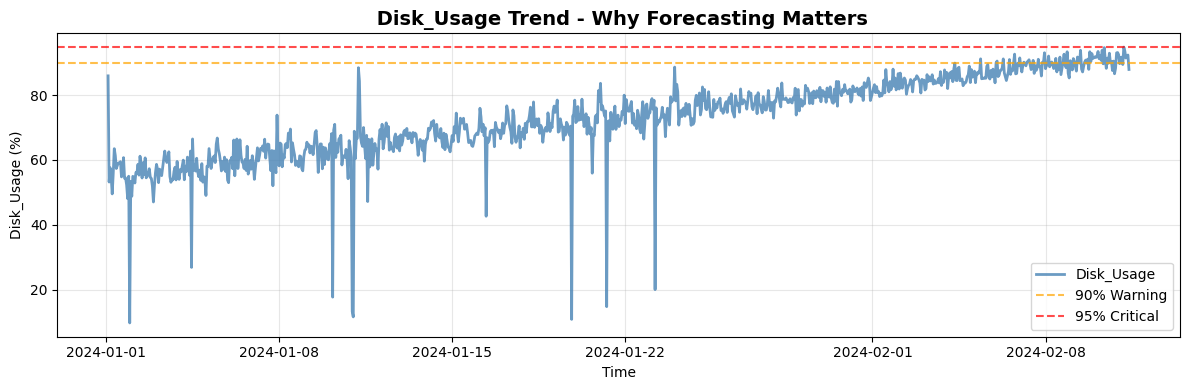

 Business Impact:
Reactive: Wait for Disk_Usage to hit 95% and scramble
Proactive: Predict when Disk_Usage will hit 95% and prevent it


In [2]:
# SOLUTION: System health visualization with capacity thresholds

plt.figure(figsize=(12, 4))

# Plot the critical metric trend
plt.plot(df.index, df[critical_metric], color='steelblue', linewidth=2, alpha=0.8, label=critical_metric)

# Add appropriate threshold lines based on the metric
if critical_metric == 'Disk_Usage':
    warning, critical = 90, 95
elif critical_metric == 'CPU_Usage':
    warning, critical = 80, 90
elif critical_metric == 'RAM_Usage':
    warning, critical = 85, 95
else:  # Network
    warning, critical = 75, 90

plt.axhline(y=warning, color='orange', linestyle='--', alpha=0.7, label=f'{warning}% Warning')
plt.axhline(y=critical, color='red', linestyle='--', alpha=0.7, label=f'{critical}% Critical')

plt.title(f' {critical_metric} Trend - Why Forecasting Matters', fontsize=14, fontweight='bold')
plt.ylabel(f'{critical_metric} (%)')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f" Business Impact:")
print(f"Reactive: Wait for {critical_metric} to hit {critical}% and scramble")
print(f"Proactive: Predict when {critical_metric} will hit {critical}% and prevent it")

## Lesson 4.2 — Time-Series Components

**Goal**: Decompose time series into trend, seasonality, and residual components

### Demonstration: Time Series Decomposition

Let's break down our time series to understand its underlying patterns:

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Focus on our critical metric
ts_data = df[critical_metric].dropna()

# Resample for cleaner analysis
print(" Resampling data for decomposition...")
if len(ts_data) > 1000:
    resample_freq = '6h'
elif len(ts_data) > 500:
    resample_freq = '12h'
else:
    resample_freq = 'D'
    
ts_resampled = ts_data.resample(resample_freq).mean().ffill()
print(f"Resampled to {resample_freq}: {len(ts_resampled)} points")

# Perform decomposition
print(" Decomposing time series...")
decomposition = seasonal_decompose(ts_resampled, model='additive', period=7)

print(" Components extracted: Trend, Seasonality, and Residuals")

 Resampling data for decomposition...
Resampled to 12h: 83 points
 Decomposing time series...
 Components extracted: Trend, Seasonality, and Residuals


### Your Turn: Create Decomposition Visualization

Visualize the three components of the time series:

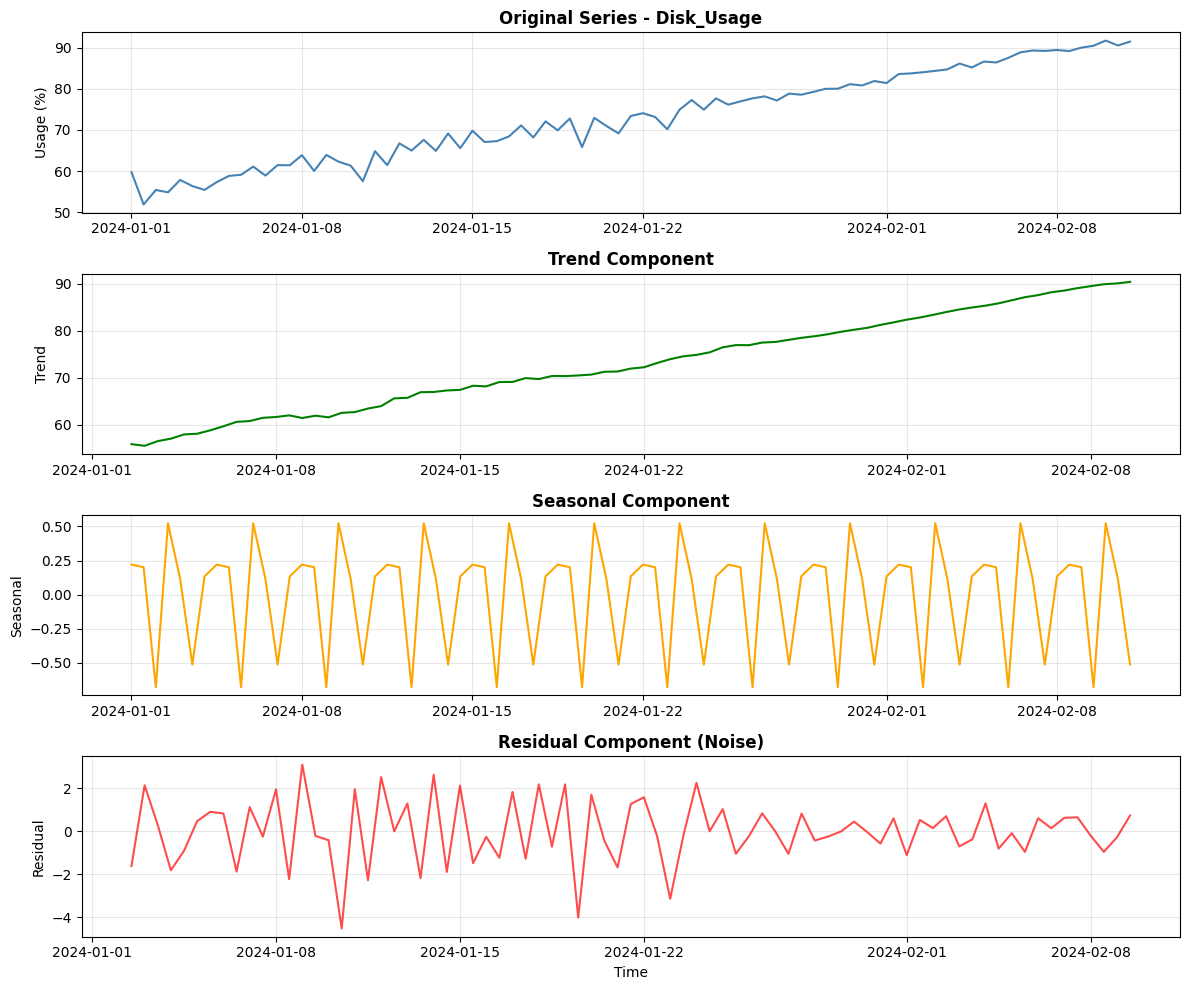

 Component Analysis:
Trend: Downward direction
Seasonality: 1.20% variation
Residuals: 1.49% standard deviation (noise)


In [5]:
# SOLUTION: Time series decomposition plot

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Plot original series on axes[0]
axes[0].plot(ts_resampled.index, ts_resampled.values, color='steelblue')
axes[0].set_title(f'Original Series - {critical_metric}', fontweight='bold')
axes[0].set_ylabel('Usage (%)')
axes[0].grid(True, alpha=0.3)

# Plot trend component on axes[1]
axes[1].plot(ts_resampled.index, decomposition.trend, color='green')
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Plot seasonal component on axes[2]
axes[2].plot(ts_resampled.index, decomposition.seasonal, color='orange')
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Plot residuals on axes[3]
axes[3].plot(ts_resampled.index, decomposition.resid, color='red', alpha=0.7)
axes[3].set_title('Residual Component (Noise)', fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print component insights
print(" Component Analysis:")
trend_direction = "Upward" if decomposition.trend.iloc[-1] > decomposition.trend.iloc[0] else "Downward"
print(f"Trend: {trend_direction} direction")

seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
print(f"Seasonality: {seasonal_range:.2f}% variation")

print(f"Residuals: {decomposition.resid.std():.2f}% standard deviation (noise)")

## Lesson 4.3 — Forecasting Models (SARIMA & Exponential Smoothing)

**Goal**: Train multiple forecasting models and prepare for prediction

### Demonstration: Model Training Setup

Let's prepare our data and train our first forecasting models:

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Prepare modeling data
model_data = ts_resampled

# Split into train/test (80/20)
split_idx = int(len(model_data) * 0.8)
train = model_data.iloc[:split_idx]
test = model_data.iloc[split_idx:]

print(" Data Split for Model Training:")
print(f"Training: {train.index.min()} to {train.index.max()} ({len(train)} points)")
print(f"Testing:  {test.index.min()} to {test.index.max()} ({len(test)} points)")

# Train SARIMA model
print("\n Training SARIMA model...")
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_fit = sarima_model.fit(disp=False)
print(" SARIMA model trained successfully")

# Train Exponential Smoothing model
print(" Training Exponential Smoothing model...")
es_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
es_fit = es_model.fit()
print(" Exponential Smoothing model trained successfully")

 Data Split for Model Training:
Training: 2024-01-01 00:00:00 to 2024-02-02 12:00:00 (66 points)
Testing:  2024-02-03 00:00:00 to 2024-02-11 00:00:00 (17 points)

 Training SARIMA model...
 SARIMA model trained successfully
 Training Exponential Smoothing model...
 Exponential Smoothing model trained successfully


### Your Turn: Generate Model Predictions

Use the trained models to generate forecasts for the test period:

In [7]:
# SOLUTION: Generate forecasts from both models

print(" Generating model predictions...")

# Generate SARIMA forecast for test period
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Generate Exponential Smoothing forecast for test period
es_forecast = es_fit.forecast(steps=len(test))

print(f" SARIMA forecast: {len(sarima_forecast)} periods")
print(f" Exponential Smoothing forecast: {len(es_forecast)} periods")
print(f" Actual test data: {len(test)} periods")

# Preview first few predictions
print("\n First 5 Predictions:")
print(f"SARIMA: {sarima_forecast[:5].values}")
print(f"Exp Smooth: {es_forecast[:5].values}")
print(f"Actual: {test[:5].values}")

 Generating model predictions...
 SARIMA forecast: 17 periods
 Exponential Smoothing forecast: 17 periods
 Actual test data: 17 periods

 First 5 Predictions:
SARIMA: [84.00408933 84.46387303 83.75935974 85.51888223 86.27657419]
Exp Smooth: [84.40611598 84.28455142 83.97374042 85.40369179 86.41471499]
Actual: [84.35125167 84.70903044 86.13179914 85.17282735 86.61952058]


## Lesson 4.4 — Evaluating Forecast Accuracy

**Goal**: Quantify model performance using standard accuracy metrics

### Demonstration: Accuracy Metrics Calculation

Let's calculate how accurate our forecasts are compared to actual values:

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate accuracy metrics function
def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    # Mean Absolute Percentage Error (MAPE)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"\n{model_name}:")
    print(f"  MAE:  {mae:.2f}% (Mean Absolute Error)")
    print(f"  RMSE: {rmse:.2f}% (Root Mean Squared Error)")
    print(f"  MAPE: {mape:.2f}% (Mean Absolute Percentage Error)")
    
    return mae, rmse, mape

print(" Model Accuracy Evaluation:")
print("=" * 50)

# Calculate metrics for both models
sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(test.values, sarima_forecast, "SARIMA")
es_mae, es_rmse, es_mape = calculate_metrics(test.values, es_forecast, "Exponential Smoothing")

 Model Accuracy Evaluation:

SARIMA:
  MAE:  1.06% (Mean Absolute Error)
  RMSE: 1.29% (Root Mean Squared Error)
  MAPE: 1.20% (Mean Absolute Percentage Error)

Exponential Smoothing:
  MAE:  1.01% (Mean Absolute Error)
  RMSE: 1.24% (Root Mean Squared Error)
  MAPE: 1.13% (Mean Absolute Percentage Error)


### Your Turn: Select Best Model and Interpret Results

Compare model performance and select the best one for capacity planning:

In [9]:
# SOLUTION: Select best model and interpret results

print(" Model Selection Analysis:")

# Compare MAPE values and select best model
if sarima_mape < es_mape:
    best_model = sarima_fit
    best_forecast = sarima_forecast
    best_model_name = "SARIMA"
    best_mape = sarima_mape
else:
    best_model = es_fit
    best_forecast = es_forecast
    best_model_name = "Exponential Smoothing"
    best_mape = es_mape

print(f"\n Best Model Selected: {best_model_name}")
print(f"   MAPE: {best_mape:.2f}% (lower is better)")

# Interpret what the MAPE means for business decisions
if best_mape < 5:
    accuracy_level = "Excellent"
elif best_mape < 10:
    accuracy_level = "Good"
elif best_mape < 20:
    accuracy_level = "Reasonable"
else:
    accuracy_level = "Needs improvement"

print(f"   Business Interpretation: {accuracy_level} accuracy for capacity planning")

 Model Selection Analysis:

 Best Model Selected: Exponential Smoothing
   MAPE: 1.13% (lower is better)
   Business Interpretation: Excellent accuracy for capacity planning


## Lesson 4.5 — Visualizing Forecast Results

**Goal**: Create clear visualizations comparing forecasts with actual values

### Demonstration: Forecast Visualization Setup

Let's create a comprehensive visualization showing model performance:

In [10]:
# Prepare confidence intervals for the best model
if best_model_name == "SARIMA":
    forecast_obj = best_model.get_forecast(steps=len(test))
    conf_int = forecast_obj.conf_int()
else:
    # Simple confidence interval for Exponential Smoothing
    std_error = np.std(test.values - best_forecast)
    conf_int_lower = best_forecast - 1.96 * std_error
    conf_int_upper = best_forecast + 1.96 * std_error

print(" Preparing forecast visualization...")
print(f"Using best model: {best_model_name}")
print(f"Confidence intervals calculated for uncertainty estimation")

 Preparing forecast visualization...
Using best model: Exponential Smoothing
Confidence intervals calculated for uncertainty estimation


### Your Turn: Create Forecast vs Actual Plot

Build a comprehensive visualization showing historical data, forecasts, and confidence intervals:

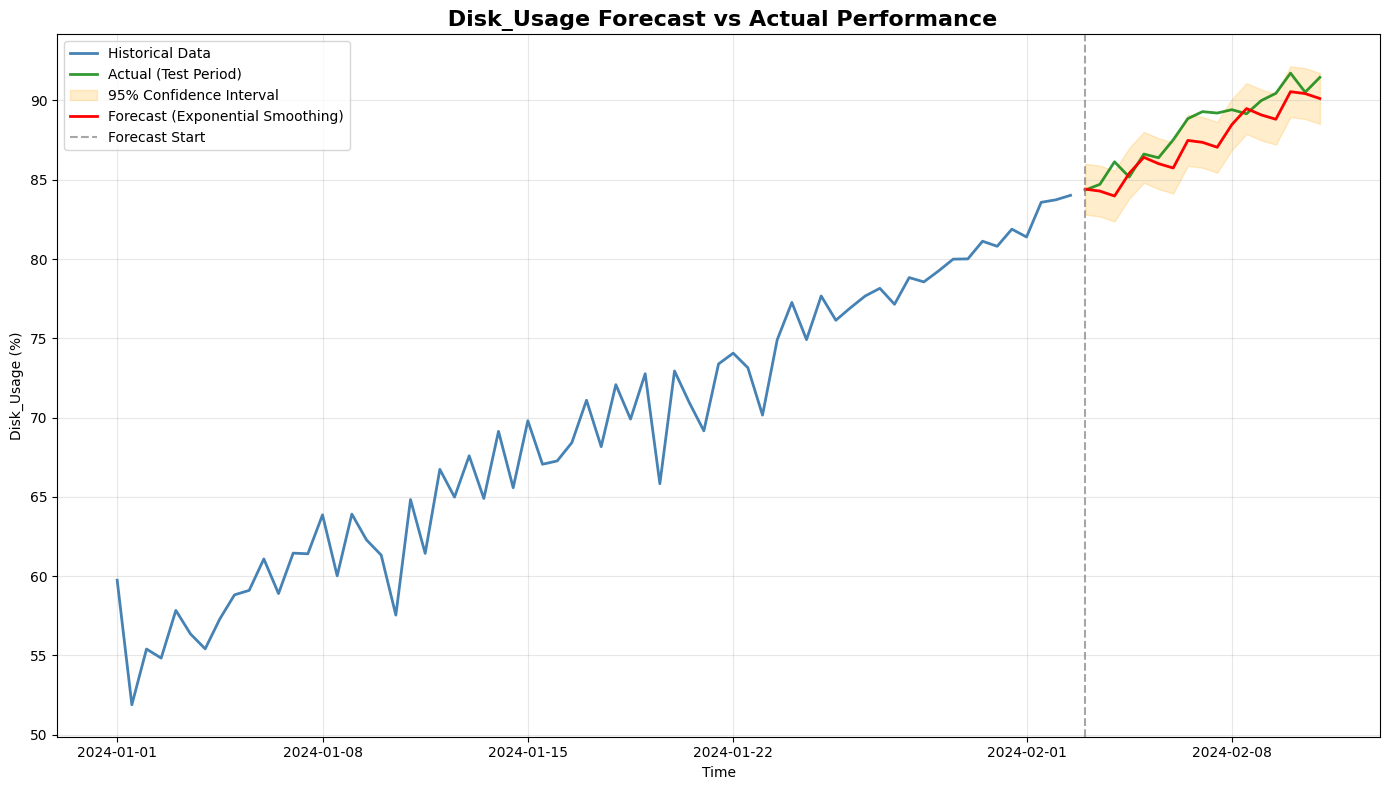

 Forecast Visualization Complete!
Key elements shown:
• Historical training data
• Actual values from test period
• Model predictions with confidence intervals
• Forecast uncertainty (shaded area)


In [11]:
# SOLUTION: Create forecast visualization with confidence intervals

plt.figure(figsize=(14, 8))

# Plot training data
plt.plot(train.index, train.values, label='Historical Data', color='steelblue', linewidth=2)

# Plot test data (actual values)
plt.plot(test.index, test.values, label='Actual (Test Period)', color='green', linewidth=2, alpha=0.8)

# Plot forecast with confidence interval
if best_model_name == "SARIMA":
    forecast_obj = best_model.get_forecast(steps=len(test))
    conf_int = forecast_obj.conf_int()
    plt.fill_between(test.index,
                    conf_int.iloc[:, 0],
                    conf_int.iloc[:, 1],
                    alpha=0.2, color='orange', label='95% Confidence Interval')
else:
    std_error = np.std(test.values - best_forecast)
    plt.fill_between(test.index,
                    best_forecast - 1.96 * std_error,
                    best_forecast + 1.96 * std_error,
                    alpha=0.2, color='orange', label='95% Confidence Interval')

plt.plot(test.index, best_forecast, label=f'Forecast ({best_model_name})', color='red', linewidth=2)

# Add forecast start line and labels
plt.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title(f' {critical_metric} Forecast vs Actual Performance', fontsize=16, fontweight='bold')
plt.ylabel(f'{critical_metric} (%)')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" Forecast Visualization Complete!")
print("Key elements shown:")
print("• Historical training data")
print("• Actual values from test period") 
print("• Model predictions with confidence intervals")
print("• Forecast uncertainty (shaded area)")

## Lesson 4.6 — Predicting Capacity Thresholds

**Goal**: Forecast future capacity needs and predict when thresholds will be breached

### Demonstration: Future Forecasting Setup

Let's set up our future forecast and define capacity thresholds:

In [12]:
# Define forecast period based on data frequency
if resample_freq == 'D':
    forecast_periods = 30  # 30 days
elif resample_freq == '12H':
    forecast_periods = 60  # 30 days
else:  # 6H
    forecast_periods = 120  # 30 days

# Generate future dates
last_date = model_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), 
                            periods=forecast_periods, 
                            freq=resample_freq)

# Define capacity thresholds
if critical_metric == 'Disk_Usage':
    warning_threshold, critical_threshold = 90, 95
elif critical_metric == 'CPU_Usage':
    warning_threshold, critical_threshold = 80, 90
elif critical_metric == 'RAM_Usage':
    warning_threshold, critical_threshold = 85, 95
else:  # Network
    warning_threshold, critical_threshold = 75, 90

print(f" Future Forecast Setup:")
print(f"Forecast periods: {forecast_periods} ({resample_freq} intervals)")
print(f"Capacity thresholds: {warning_threshold}% (warning), {critical_threshold}% (critical)")
print(f"Forecast range: {future_dates[0]} to {future_dates[-1]}")

 Future Forecast Setup:
Forecast periods: 120 (12h intervals)
Capacity thresholds: 90% (warning), 95% (critical)
Forecast range: 2024-02-11 01:00:00 to 2024-04-10 13:00:00


### Your Turn: Generate Future Forecast and Detect Threshold Breaches

Predict future values and identify when capacity thresholds will be breached:

In [13]:
# SOLUTION: Generate future forecast and detect threshold breaches

print(" Capacity Threshold Analysis")
print("=" * 50)

# Generate future forecast using best model
if best_model_name == "SARIMA":
    future_forecast_obj = best_model.get_forecast(steps=forecast_periods)
    future_forecast = future_forecast_obj.predicted_mean
else:
    future_forecast = best_model.forecast(steps=forecast_periods)

# Find when forecasts cross warning threshold
warning_breach_idx = np.where(future_forecast >= warning_threshold)[0]

# Find when forecasts cross critical threshold  
critical_breach_idx = np.where(future_forecast >= critical_threshold)[0]

print(f" {forecast_periods}-Period Capacity Forecast:")

# Print warning threshold breach details
if len(warning_breach_idx) > 0:
    warning_date = future_dates[warning_breach_idx[0]]
    time_to_warning = warning_date - last_date
    print(f"  WARNING: Will hit {warning_threshold}% on {warning_date}")
    print(f"   Time until breach: {time_to_warning}")
else:
    print(f" No {warning_threshold}% warning threshold breach")

# Print critical threshold breach details
if len(critical_breach_idx) > 0:
    critical_date = future_dates[critical_breach_idx[0]]
    time_to_critical = critical_date - last_date
    print(f" CRITICAL: Will hit {critical_threshold}% on {critical_date}")
    print(f"   Time until breach: {time_to_critical}")
    print(f"    URGENT ACTION REQUIRED!")
else:
    print(f" No {critical_threshold}% critical threshold breach")

 Capacity Threshold Analysis
 120-Period Capacity Forecast:
   Time until breach: 7 days 01:00:00
 CRITICAL: Will hit 95% on 2024-02-23 13:00:00
   Time until breach: 12 days 13:00:00
    URGENT ACTION REQUIRED!


## Lesson 4.7 — Building a Proactive Dashboard

**Goal**: Create a comprehensive dashboard for operational visibility

### Demonstration: Dashboard Setup

Let's prepare the components for our proactive monitoring dashboard:

In [14]:
# Prepare confidence intervals for future forecast
if best_model_name == "SARIMA":
    future_conf_int = future_forecast_obj.conf_int()
    future_ci_lower = future_conf_int.iloc[:, 0]
    future_ci_upper = future_conf_int.iloc[:, 1]
else:
    # Simple confidence interval
    std_error = np.std(test.values - best_forecast)
    future_ci_lower = future_forecast - 1.96 * std_error
    future_ci_upper = future_forecast + 1.96 * std_error

# Ensure forecasts stay within 0-100% bounds
future_forecast = np.clip(future_forecast, 0, 100)
future_ci_lower = np.clip(future_ci_lower, 0, 100)
future_ci_upper = np.clip(future_ci_upper, 0, 100)

print(" Dashboard Components Ready:")
print(f"• Historical data: {len(model_data)} points")
print(f"• Future forecast: {len(future_forecast)} periods") 
print(f"• Confidence intervals: Calculated")
print(f"• Threshold lines: {warning_threshold}% and {critical_threshold}%")

 Dashboard Components Ready:
• Historical data: 83 points
• Future forecast: 120 periods
• Confidence intervals: Calculated
• Threshold lines: 90% and 95%


### Your Turn: Create Comprehensive Proactive Dashboard

Build a two-panel dashboard showing both historical trends and detailed future forecasts:

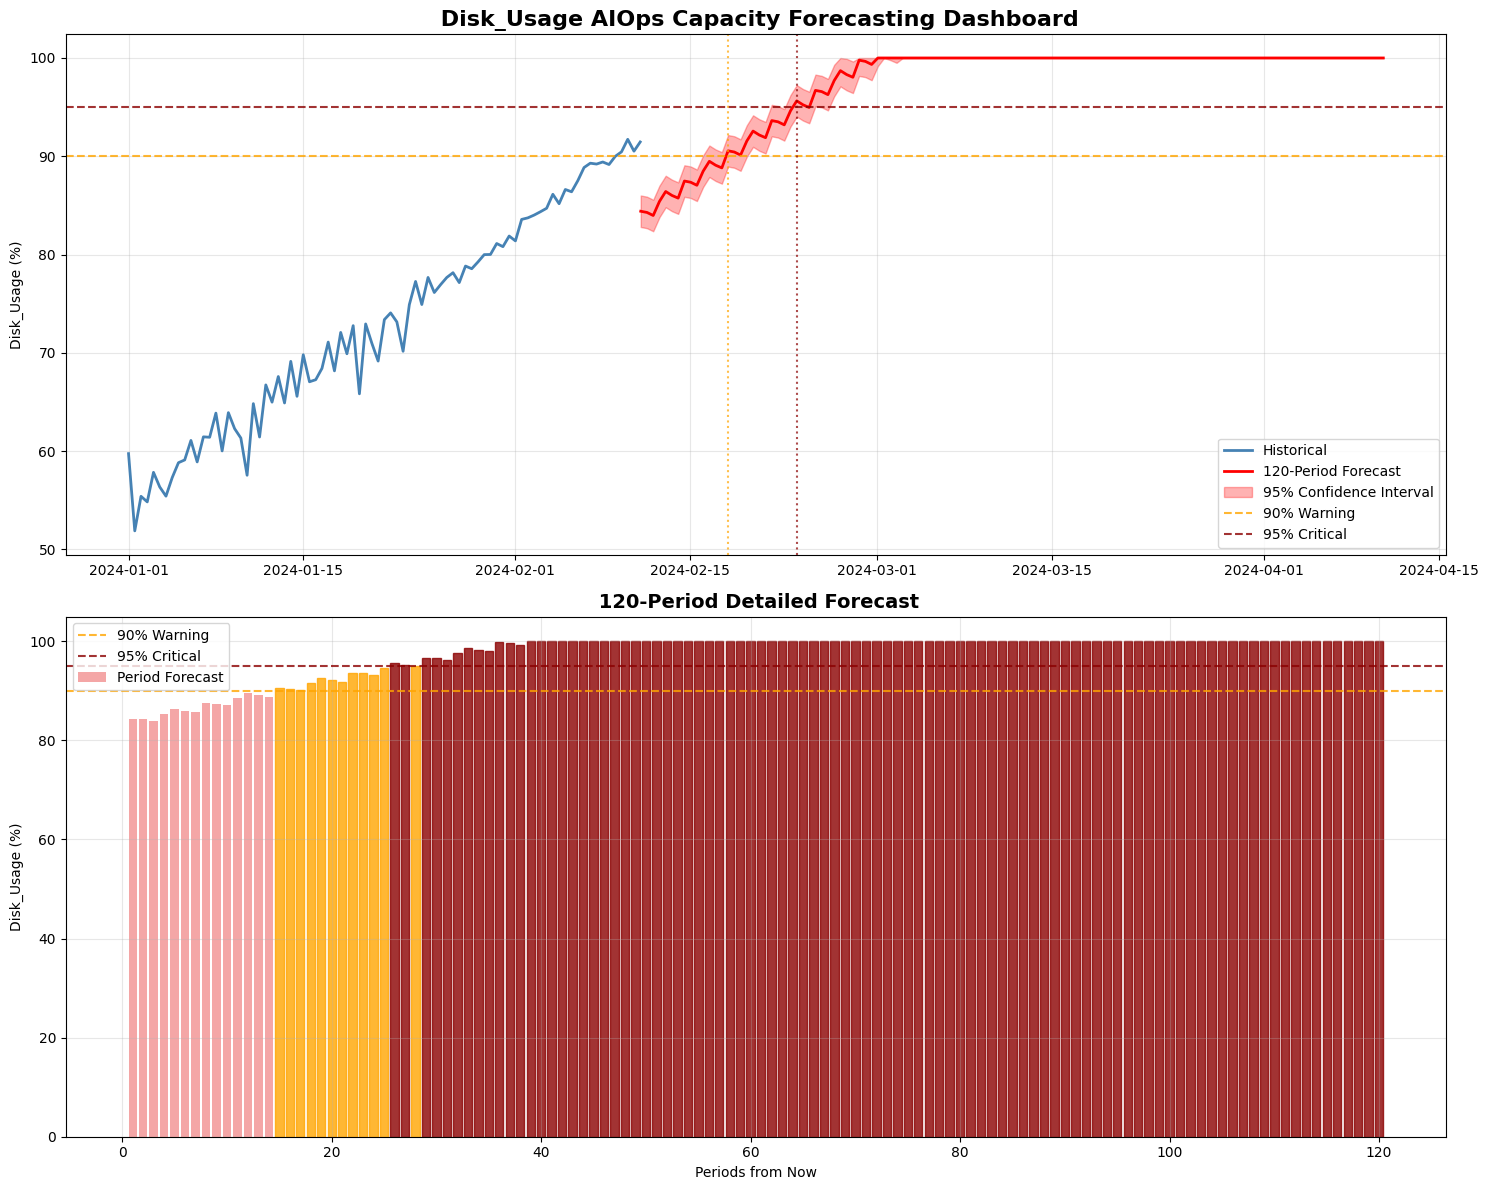

 Proactive dashboard saved: /app/notebooks/data/disk_usage_forecast_dashboard.png
 Dashboard includes:
• Complete historical trend with future forecast
• Confidence intervals showing prediction uncertainty
• Clear threshold breach markers
• Detailed period-by-period forecast view


In [15]:
# SOLUTION: Create proactive capacity planning dashboard

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Top panel: Historical + Future Forecast
# Plot historical data on ax1
ax1.plot(model_data.index, model_data.values, label='Historical', color='steelblue', linewidth=2)

# Plot future forecast with confidence interval on ax1
ax1.plot(future_dates, future_forecast, label=f'{forecast_periods}-Period Forecast', color='red', linewidth=2)
ax1.fill_between(future_dates, future_ci_lower, future_ci_upper, alpha=0.3, color='red', label='95% Confidence Interval')

# Add threshold lines and breach markers on ax1
ax1.axhline(y=warning_threshold, color='orange', linestyle='--', alpha=0.8, label=f'{warning_threshold}% Warning')
ax1.axhline(y=critical_threshold, color='darkred', linestyle='--', alpha=0.8, label=f'{critical_threshold}% Critical')

# Mark threshold breaches if any
if len(warning_breach_idx) > 0:
    ax1.axvline(x=future_dates[warning_breach_idx[0]], color='orange', linestyle=':', alpha=0.7)
if len(critical_breach_idx) > 0:
    ax1.axvline(x=future_dates[critical_breach_idx[0]], color='darkred', linestyle=':', alpha=0.7)

ax1.set_title(f' {critical_metric} AIOps Capacity Forecasting Dashboard', fontsize=16, fontweight='bold')
ax1.set_ylabel(f'{critical_metric} (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom panel: Detailed Forecast View
periods_ahead = np.arange(1, forecast_periods + 1)
# Create bar chart of future forecast on ax2
bars = ax2.bar(periods_ahead, future_forecast, color='lightcoral', alpha=0.7, label='Period Forecast')

# Color bars based on threshold levels
for i, (period, usage) in enumerate(zip(periods_ahead, future_forecast)):
    if usage >= critical_threshold:
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.8)
    elif usage >= warning_threshold:
        bars[i].set_color('orange')
        bars[i].set_alpha(0.8)

ax2.axhline(y=warning_threshold, color='orange', linestyle='--', alpha=0.8, label=f'{warning_threshold}% Warning')
ax2.axhline(y=critical_threshold, color='darkred', linestyle='--', alpha=0.8, label=f'{critical_threshold}% Critical')

ax2.set_title(f' {forecast_periods}-Period Detailed Forecast', fontsize=14, fontweight='bold')
ax2.set_xlabel('Periods from Now')
ax2.set_ylabel(f'{critical_metric} (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save dashboard
dashboard_path = f'/app/notebooks/data/{critical_metric.lower()}_forecast_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Proactive dashboard saved: {dashboard_path}")
print(" Dashboard includes:")
print("• Complete historical trend with future forecast")
print("• Confidence intervals showing prediction uncertainty")
print("• Clear threshold breach markers")
print("• Detailed period-by-period forecast view")

## Lesson 4.8 — Module Recap & Export

**Goal**: Export forecast data and summarize key insights for operations teams

### Demonstration: Data Export Setup

Let's prepare our forecast data for export and operational use:

In [16]:
# Create comprehensive forecast dataset
forecast_df = pd.DataFrame({
    'timestamp': future_dates,
    f'{critical_metric.lower()}_forecast': future_forecast,
    'confidence_lower': future_ci_lower,
    'confidence_upper': future_ci_upper,
    f'warning_threshold_{warning_threshold}': warning_threshold,
    f'critical_threshold_{critical_threshold}': critical_threshold
})

# Add threshold breach indicators
forecast_df['above_warning'] = forecast_df[f'{critical_metric.lower()}_forecast'] >= warning_threshold
forecast_df['above_critical'] = forecast_df[f'{critical_metric.lower()}_forecast'] >= critical_threshold

print(" Forecast Data Prepared for Export:")
print(f"Dataset shape: {forecast_df.shape}")
print(f"Columns: {list(forecast_df.columns)}")
print(f"Time range: {forecast_df['timestamp'].min()} to {forecast_df['timestamp'].max()}")

 Forecast Data Prepared for Export:
Dataset shape: (120, 8)
Columns: ['timestamp', 'disk_usage_forecast', 'confidence_lower', 'confidence_upper', 'warning_threshold_90', 'critical_threshold_95', 'above_warning', 'above_critical']
Time range: 2024-02-11 01:00:00 to 2024-04-10 13:00:00


### Your Turn: Export Data and Create Executive Summary

Save the forecast data and generate a business-focused summary:

In [17]:
# SOLUTION: Export forecast data and create executive summary

# Export forecast data to CSV
export_path = f'/app/notebooks/data/{critical_metric.lower()}_forecast.csv'
forecast_df.to_csv(export_path, index=False)

print(" CAPACITY FORECASTING EXECUTIVE SUMMARY")
print("=" * 50)

print(f"\n Forecast Overview:")
print(f"   Metric: {critical_metric}")
print(f"   Model: {best_model_name} (MAPE: {best_mape:.1f}%)")
print(f"   Current Usage: {model_data.iloc[-1]:.1f}%")
print(f"   Forecast Periods: {forecast_periods}")

# Calculate and display threshold breach summary
warning_breaches = forecast_df[forecast_df['above_warning']]
critical_breaches = forecast_df[forecast_df['above_critical']]

print(f"\n Capacity Risk Assessment:")
if len(warning_breaches) > 0:
    first_warning = warning_breaches.iloc[0]['timestamp']
    print(f"     Warning Threshold ({warning_threshold}%): {first_warning}")
else:
    print(f"    No warning threshold breaches")

if len(critical_breaches) > 0:
    first_critical = critical_breaches.iloc[0]['timestamp']
    print(f"    Critical Threshold ({critical_threshold}%): {first_critical}")
    print(f"    URGENT: Infrastructure upgrade required!")
else:
    print(f"    No critical threshold breaches")

print(f"\n Data Exported: {export_path}")
print(f" Dashboard: {dashboard_path}")

print(f"\n Business Impact: Transformed from reactive to proactive operations!")
print("   Now you can prevent capacity issues instead of reacting to them.")

 CAPACITY FORECASTING EXECUTIVE SUMMARY

 Forecast Overview:
   Metric: Disk_Usage
   Model: Exponential Smoothing (MAPE: 1.1%)
   Current Usage: 91.5%
   Forecast Periods: 120

 Capacity Risk Assessment:
     Warning Threshold (90%): 2024-02-18 01:00:00
    Critical Threshold (95%): 2024-02-23 13:00:00
    URGENT: Infrastructure upgrade required!

 Data Exported: /app/notebooks/data/disk_usage_forecast.csv
 Dashboard: /app/notebooks/data/disk_usage_forecast_dashboard.png

 Business Impact: Transformed from reactive to proactive operations!
   Now you can prevent capacity issues instead of reacting to them.


##  Module 4 Complete!

Congratulations! You've successfully built a complete AIOps forecasting pipeline that can predict capacity issues before they impact your systems.

**Key Skills Mastered:**
- Time series decomposition and analysis
- Multiple forecasting model training (SARIMA, Exponential Smoothing)
- Forecast accuracy evaluation and model selection
- Capacity threshold prediction and breach detection
- Proactive dashboard creation for operations visibility

**Operational Impact:** You can now provide data-driven capacity planning recommendations and prevent outages before they happen!